In [1]:
## Import Required Libraries
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
## Create SQLite Database

conn = sqlite3.connect("sales_data.db")
cursor = conn.cursor()

In [3]:
## Create Sales Table

cursor.execute("""
CREATE TABLE IF NOT EXISTS sales (
    order_id INTEGER,
    product TEXT,
    quantity INTEGER,
    price REAL
)
""")

In [16]:
## Insert Data
sales_data = [
    (1, 'Laptop', 2, 50000),
    (2, 'Mobile', 5, 15000),
    (3, 'Headphone', 10, 2000),
    (4, 'Keyboard', 4, 1200),
    (5, 'Mouse', 6, 800),
    (6, 'Monitor', 3, 12000),
    (7, 'Printer', 2, 8000),
    (8, 'Tablet', 4, 18000),
    (9, 'Speaker', 5, 3000),
    (10, 'Webcam', 7, 2500),
    (11, 'Laptop', 1, 50000),
    (12, 'Mobile', 3, 15000),
    (13, 'Headphone', 8, 2000),
    (14, 'Keyboard', 5, 1200),
    (15, 'Mouse', 4, 800),
    (16, 'Monitor', 2, 12000),
    (17, 'Printer', 1, 8000),
    (18, 'Tablet', 2, 18000),
    (19, 'Speaker', 3, 3000),
    (20, 'Webcam', 5, 2500)
]
cursor.executemany(
    "INSERT INTO sales VALUES (?,?,?,?)",
    sales_data
)

conn.commit()

In [17]:
## Table view

df = pd.read_sql_query("SELECT * FROM sales", conn)
print(df.head())

   order_id    product  quantity    price
0         1     Laptop         2  50000.0
1         2     Mobile         5  15000.0
2         3  Headphone        10   2000.0
3         4   Keyboard         4   1200.0
4         5      Mouse         6    800.0


In [18]:
## Write SQL Query

query = """
SELECT
product,
SUM(quantity) AS total_qty,
SUM(quantity * price) AS revenue
FROM sales
GROUP BY product
"""

In [20]:
## Load SQL Data into Python

df = pd.read_sql_query(query, conn)

In [21]:
## Print Results
print(df)

     product  total_qty   revenue
0  Headphone         54  108000.0
1   Keyboard         27   32400.0
2     Laptop          9  450000.0
3     Mobile         24  360000.0
4    Monitor         15  180000.0
5      Mouse         30   24000.0
6    Printer          9   72000.0
7    Speaker         24   72000.0
8     Tablet         18  324000.0
9     Webcam         36   90000.0


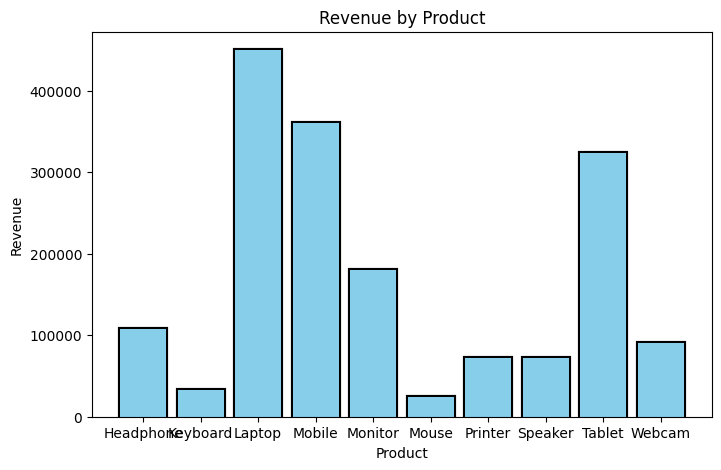

In [38]:
## Create Revenue Bar Chart

plt.figure(figsize=(8,5))

plt.bar(df['product'], df['revenue'],  edgecolor='black',
    linewidth=3)

plt.title("Revenue by Product")
plt.xlabel("Product")
plt.ylabel("Revenue")
plt.bar(df['product'], df['revenue'], color='skyblue')

plt.show()

In [24]:
#3 Save Chart

plt.savefig("sales_chart.png")

<Figure size 640x480 with 0 Axes>

In [25]:
## Close Database Connection

conn.close()